In [18]:
%load_ext autoreload
%autoreload 2

# VIMA demo

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scanpy as sc
import os, glob, tifffile
import vima
import torch
torch.set_default_device('mps') # uncomment if running on a MacBook
vima.set_seed(0, deterministic=True) # for reproducibility
os.makedirs(f'./RA/_results', exist_ok=True) # create directory for results

In this demo, we will illustrate how to preprocess and then analyze a case-control spatial dataset using VIMA. The dataset we use for demonstration is an immumofluorescence dataset of synovial biopsies from rheumatoid arthritis patients, but VIMA can be similarly applied to any spatial modality.

## Download data

The raw input files in this format that are necessary for the demo are posted as a [zenodo record TODO](https://zenodo.org/records/***). Let's download them now. Please note that this requires substantial disk space (approximately 30GB) as these are high-resolution `qptiff` files.

In [ ]:
import requests

record_id = "20087925"
r = requests.get(f"https://zenodo.org/api/records/{record_id}")
files = r.json()["files"]
target_dir = "./data/IF/raw"

os.makedirs(target_dir, exist_ok=True)
for f in files:
    url = f["links"]["self"]
    fname = f["key"]
    print(f"Downloading {fname}...")
    mytargetdir = f'{target_dir}/..' if fname == 'if-metadata.csv' else target_dir
    with requests.get(url, stream=True) as r:
        with open(f"{target_dir}/{fname}", "wb") as out:
            for chunk in r.iter_content(chunk_size=8192):
                out.write(chunk)

RA_raw.tar.gz already exists. Skipping download.
Decompressing RA_raw.tar.gz...
Decompressed into ./.


## Overview of the `vima` workflow

The `vima` workflow has three major parts: 1) preprocessing, whereby the marker levels (or expression counts) in the pixels are normalized, non-spatial batch effects and sample-specific artifacts are removed, and the markers are converted into meta-markers, 2) model training, and 3) case-control analysis

## 1. Preprocessing

We first define three key functions that will tell `vima` 1) how to read in a raw data file into a 3D array whose dimensions are (y, x, marker), 2) what counts as tissue vs background, and 3) how to normalize the pixels in a given sample by autofluorescence.

NB: Specifying this is not necessary in spatial transcriptomics (ST) datasets; there, `vima`'s default functions are sufficient. Please stay tuned for a ST-specific demo.

In [13]:
# 1. define how to read the raw data into 3D arrays for a given file
def load(path):
    sid = path.split('/')[-1].split('.')[0] # replace this with code to determine the sample ID of each sample from its filepath
    data = np.ascontiguousarray(tifffile.TiffFile(path).series[0].asarray().transpose(1,2,0)) # replace this with code to load your image from its filepath
    return sid, data

# 2. define how tissue is differentiated from background
def get_foreground(s):
    if s.name == '300-0529_Scan1':
        s = s.where(s.x < 12500, 0) # we manually remove part of this specific sample because of an
                                    # area of artifact so large that it skews our QC
    return vima.pp.nonst.foreground_mask_if(s, real_markers, neg_ctrls, 0.1, 12, blur_width=5) # for other samples, use standard vima method based on otsu thresholding

# 3. define how pixel-level counts are normalized to account for autofluorescence
markers = ['DAPI', 'CLIC5', 'CD34', 'HLADR', 'CD3', 'CD90', 'CD68', 'AF']
real_markers = markers[:-1]
neg_ctrls = markers[-1:]
def norm_by_AF(X):
    return real_markers, (X[:,:-1]) / (1+X[:,-1])[:,None]

We now rasterize the raw data at the resolution needed for `vima`, annotate what is tissue and what is background, and normalize each pixel.

In [16]:
rawdatafiles = glob.glob(f'./data/IF/raw/*.qptiff')
orig_pixel_size = 0.5 # size of each pixel in the raw data in microns
resolution = 10 # size of each of vima's pixels in microns
outdir = f'data/IF/{resolution}u' # (vima's default resolution is 10 microns per pixel)

repname = f'pca_k={nmetamarkers}_harmony'
vima.pp.nonst.prepare(load=load,
                      filepaths=rawdatafiles,
                      orig_pixel_size=orig_pixel_size,
                      markers=markers,
                      get_foreground=get_foreground,
                      norm_by_background=norm_by_AF,
                      outdir=outdir,
                      pixel_size=resolution,
                      plot=True)

Downsampling...


100%|███████████████████████████████████████████████████████████████| 27/27 [12:54<00:00, 28.69s/it]


Computing normalization factor and dataset-wide mean and variance per marker...


100%|███████████████████████████████████████████████████████████████| 27/27 [00:09<00:00,  3.00it/s]


Normalizing and writing


100%|███████████████████████████████████████████████████████████████| 27/27 [00:16<00:00,  1.63it/s]


We now perform pca on the pixels to reduce the number of markers and then use `harmony` to integration the pixels across samples.

**NOTE** that we recommend setting `nmetamarkers = 10` but in this dataset we have to use 5 because there are fewer than 10 metamarkers.

In [21]:

nmetamarkers = 5 # the number of metamarkers to produce; 
repname = f'metamarkers_{nmetamarkers}'
allpixels_pca = vima.pp.pca_pixels(outdir, repname, nmetamarkers=nmetamarkers)

# harmonize the meta-markers and write the results
harmpixels = vima.pp.harmonize(allpixels_pca)
vima.pp.write_harmonized(outdir, repname, harmpixels)

100%|███████████████████████████████████████████████████████████████| 27/27 [00:16<00:00,  1.59it/s]


Finally, `vima` offers some sanity checks to give us a chance to spot any obvious problems

all PCs of one sample
histogram of each pc
01234

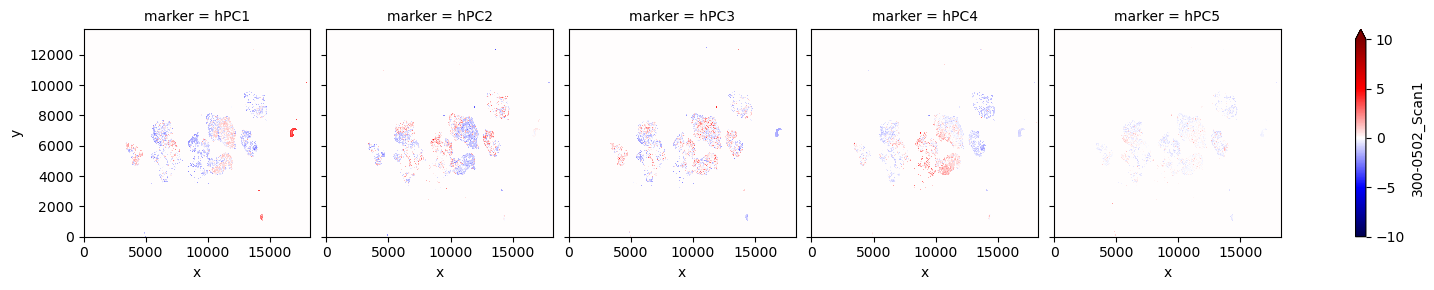

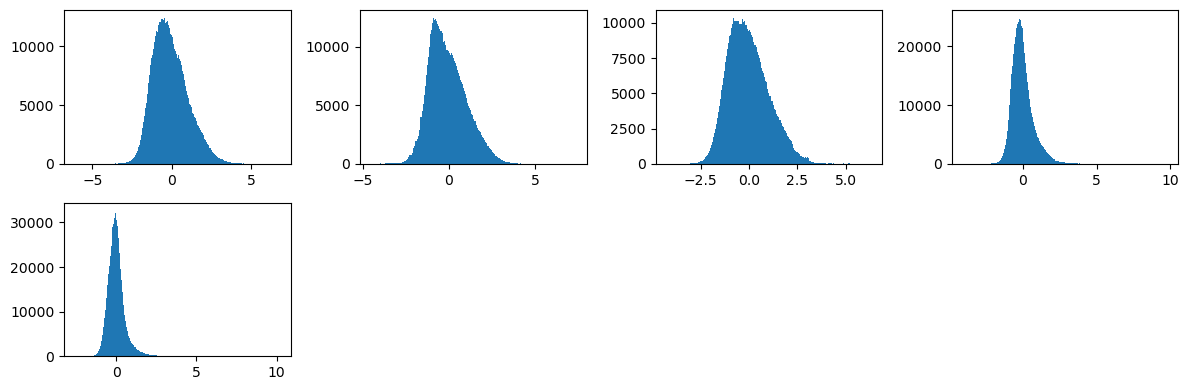

PC1 of several samples


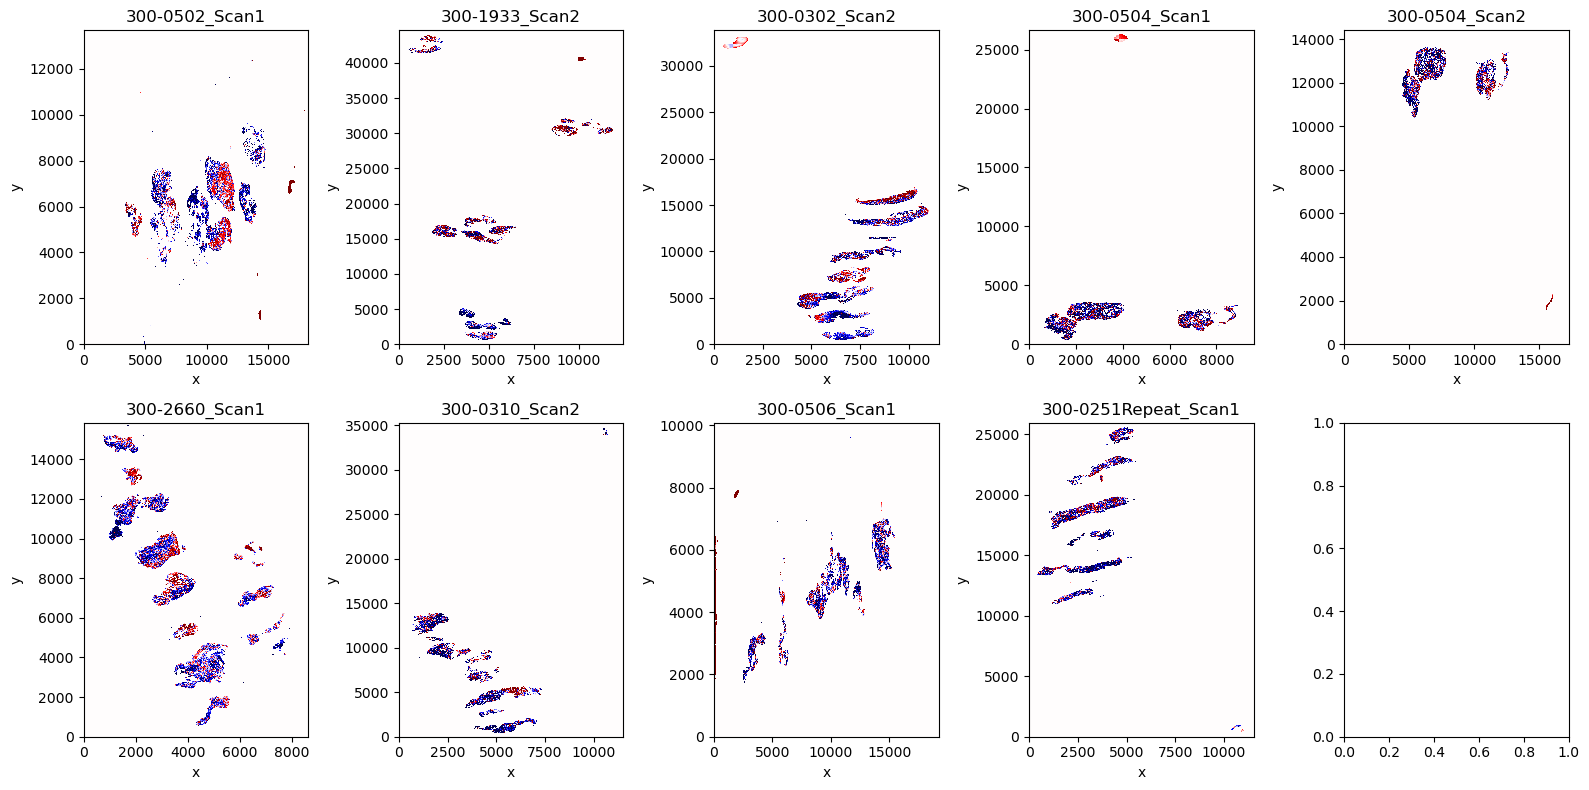

In [6]:
# visual sanity checks
vima.pp.sanity_checks(outdir, repname)

## 2. Model training

We now turn to training the `vima` model on our preprocessed data. This involves reading in the data, generating tissue patches, and training the variational autoencoder.

We first read in all the samples together with their metadata

In [24]:
# read in samples themselves
samples = vima.read_samples(f'data/IF/10u/metamarkers_5/*.nc')

100%|███████████████████████████████████████████████████████████████| 27/27 [00:05<00:00,  4.62it/s]


In [25]:
# read in and reformat sample metadata
fullmeta = pd.read_csv('data/IF/if-metadata.csv').set_index('subject_id')[['CTAP']]
fullmeta.index = fullmeta.index.str.replace('V0', '') # reformat sample names
fullmeta['fstar'] = (fullmeta.CTAP == 'F') | (fullmeta.CTAP == 'T + F') | (fullmeta.CTAP == 'E + F + M') # define our phenotype

# change samplemeta so that each row is a sample rather than a donor (since a donor can have multiple samples)
sid_to_donor = {s.sid:
                s.sid.split('_')[0].replace('Repeat','') for s in samples.values()}
samplemeta = vima.reindex_by_sid(fullmeta, sid_to_donor)

We now generate two sets of patches: one for training, and a smaller set of "high-quality" patches for the case-control analysis

In [26]:
# choose a large set of patches to train on and a smaller set to focus case/ctrl analysis on
P = vima.PatchCollection(samples, covariates={'fstar': samplemeta.fstar})
P

100%|███████████████████████████████████████████████████████████████| 27/27 [00:07<00:00,  3.46it/s]


[PatchCollection: in pytorch mode]
[PatchCollection: data augmentation is off]


PatchCollection object with npatches × width × height × nmarkers = 39302×40×40×5
	covariates: sid (27 values), fstar (2 values)

In [27]:
Pdense = P.refined(max_frac_empty=0.2)
Pdense

PatchCollection object with npatches × width × height × nmarkers = 10345×40×40×5
	covariates: sid (26 values), fstar (2 values)

Let's visualize which patches made it into Pdense to get a sense

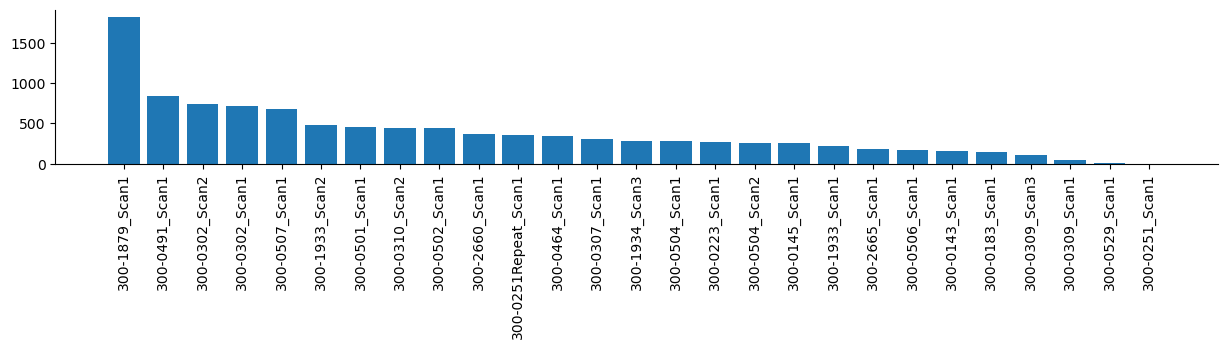

27it [00:01, 23.85it/s]
/Users/yakir/Dropbox/py/vima/src/vima/vis/spatial.py:49: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


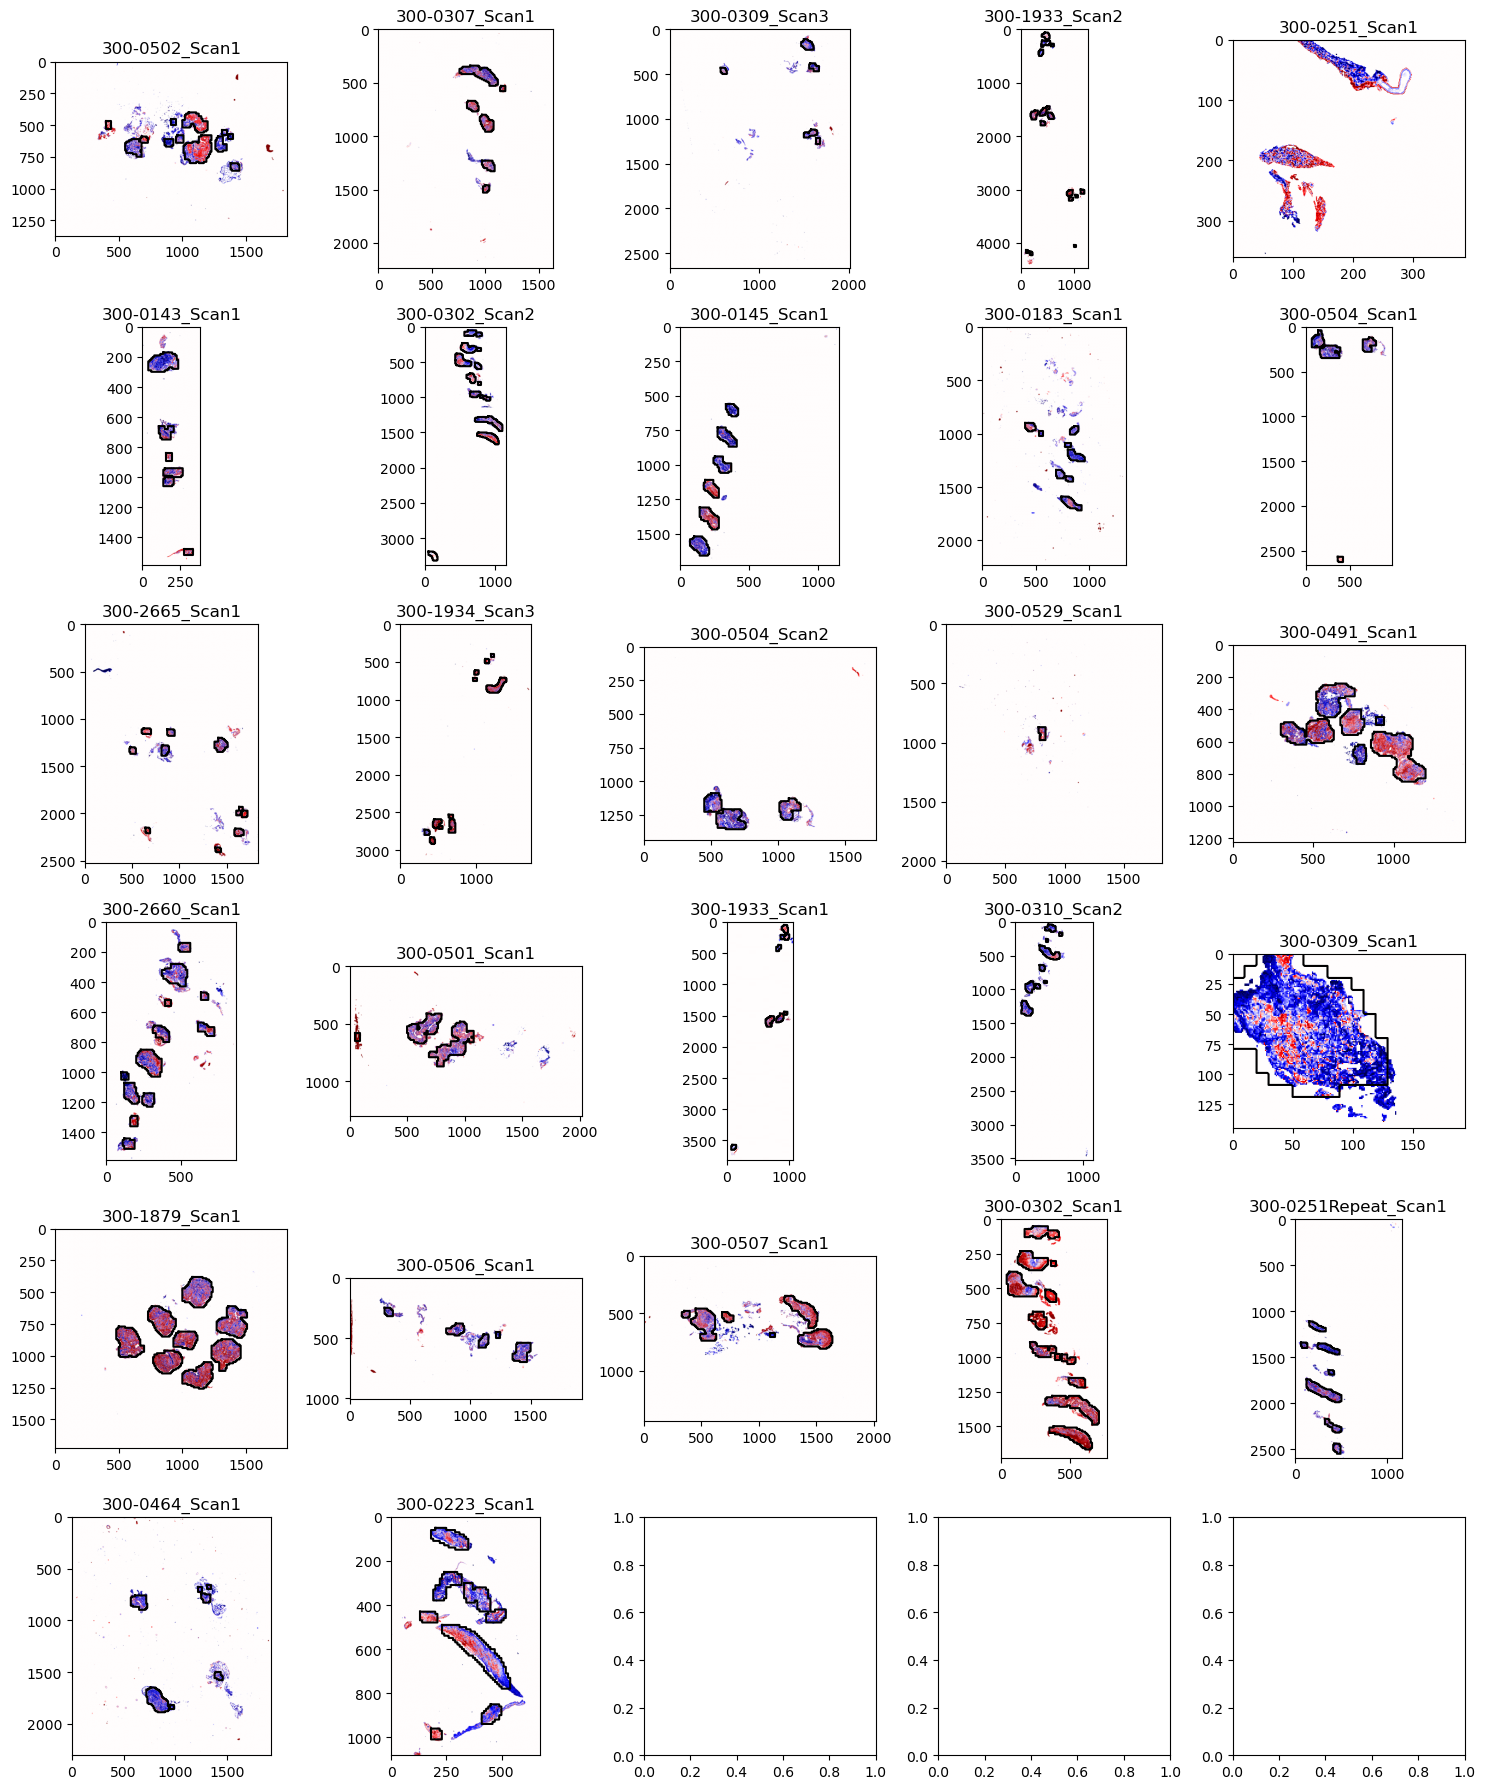

In [36]:
vima.v.plot_npatches_per_sample(samples, Pdense.meta)
vima.v.plot_samples_with_patches(samples.values(), 'hPC1', Pdense.meta, ncols=5, vmin=-2, vmax=2)

Now that we have the patches we can train the autoencoder and save an instance of the trained model.

end of epoch 20: avg val loss = 0.5896835923194885
time elapsed this epoch: 90.83 sec
total time elapsed: 2070.41 sec


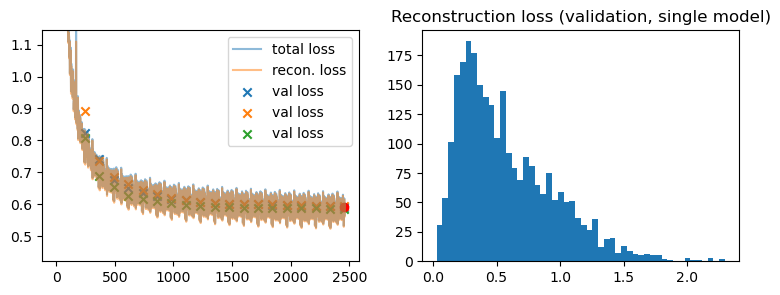

best validation losses so far across full model ensemble: [0.5917829, 0.5929472, 0.5843207]
best epochs so far across full model ensemble: [20, 20, 20]


In [ ]:
models = vima.models.cVAE(P.nmarkers, P.covariate_sizes)
log_all, log_dense = vima.fit(models, P, Pdense)
torch.save(models.state_dict(), f'data/IF/weights.pt')

Once the model is trained, we load it from disk and apply it to the set of patches that are meant for case-control analysis to generate their patch fingerprints.

In [ ]:
# load model
models = vima.models.cVAE(P.nmarkers, P.covariate_sizes, weights='data/IF/weights.pt')
ds = vima.latentreps(models, Pdense)
ds.write_h5ad(f'data/IF/fingerprints.h5ad')

applying models
in pytorch mode
data augmentation is off


100%|███████████████████████████████████████████████████████████████| 11/11 [00:08<00:00,  1.35it/s]


computing nearest-neighbor graphs


100%|███████████████████████████████████████████████████████████████| 10/10 [00:23<00:00,  2.35s/it]


## Case-control analysis

Now we can read in the the patch fingerprints and conduct the case-control analysis. The output is a global P-value for association as well as a set of significant microniches at FDR 10%.

In [ ]:
ds = vima.Fingerprints.read_h5ad('fingerprints.h5ad')
p, D = vima.association(ds, samplemeta.fstar, 'sid', donorids=samplemeta.donor)
vima.v.plot_association(D, fdr_thresh=0.1)

computing MAMs
performing association test
P = 0.00019998000199980003
Gamma p-value = 5.442012006318109e-05
         Falling back to preprocessing with `sc.pp.pca` and default params.


/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


found 5668 microniches at FDR 10%


We can now examine various properties of the output

# the global P-value for association
p

In [ ]:
# the correlation of each microniche to case-control status (aka microniche coefficient)
D.obs.mncoef

In [ ]:
# the false discovery rate at which each microniche coefficient is significant
D.obs.mncoef_fdr

And `D.obs` contains the patch metadata carried over from Pdense.meta

D.obs

# 4. Interpretation and visualization

Coming soon, but some key functions are:
- `vima.cell_type_counts` for counting how many cells of different types (or belonging to different niches) are in each patch
- `vima.expression_profiles` for computing average expression profiles of patches
- `vima.test_features` for testing patches for differences in the above features between, e.g., associated and non-associated patches
- `vima.v.plot_features` for visualizing differences in the above features between, e.g., associated and non-associated patches
- `vima.v.spatialplot` and `vima.v.annotate_spatialplot` for visualizing the associated patches in space alongside other patch features
- `vima.v.show_patches_separate` and `vima.v.show_patches_composite` for plotting select genes/proteins in, e.g., randomly chosen positively associated patches
- `vima.v.show_patches_cells` for plotting cells of different types in, e.g., randomly chosen positively associated patches